# Dual-GPU sharded runner (both Kaggle T4s)

Runs an experiment grid across **both T4 GPUs** by sharding the run-list into two subprocesses, each
pinned to one GPU via `CUDA_VISIBLE_DEVICES` (so `train.py` needs no change — each process sees its card
as `cuda:0`). Each shard writes its own CSV (no write race); we then merge + push to S3. Resumable:
completed runs (pulled from S3) are skipped.

Default grid = the **Tier-A feature ablation** (MambaLOB over all feature sets + a TLOB spot-check), but
the `GRID` cell is generic — drop in any list of run specs (e.g. Tier-B architectures later).

Setup: enable **GPU T4 x2**; secrets `GH_PAT`, `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`.
Clean S3 layout: `experiments/feature_ablation/{results,checkpoints,figures}/`.


## 1. Runtime check (expect 2 GPUs)

In [1]:
import torch, platform
print("Python:", platform.python_version(), "| Torch:", torch.__version__)
n = torch.cuda.device_count()
print(f"GPUs visible: {n}")
for i in range(n):
    print(f"  cuda:{i} = {torch.cuda.get_device_name(i)}")
assert n >= 1, "Enable GPU. For 2x speedup choose 'GPU T4 x2'."
if n < 2:
    print("Only 1 GPU -> will run a single shard (still works, no speedup).")

Python: 3.12.13 | Torch: 2.10.0+cu128
GPUs visible: 2
  cuda:0 = Tesla T4
  cuda:1 = Tesla T4


## 2. Get the project code (GH_PAT secret)

In [2]:
import sys, subprocess, pathlib
REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"
REPO_DIR = "nse-lob-capstone"
def _get_secret(name):
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v:
            return v
    except Exception:
        pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    import os
    return os.environ.get(name, "")
GITHUB_TOKEN = _get_secret("GH_PAT")
def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve()))
            return str(cand.resolve())
    return None
MODELING_DIR = None
for c in (".", REPO_DIR, "/kaggle/working/" + REPO_DIR, "/content/" + REPO_DIR):
    MODELING_DIR = add_modeling(c)
    if MODELING_DIR:
        break
if not MODELING_DIR:
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    MODELING_DIR = add_modeling(REPO_DIR)
print("modeling/ dir:", MODELING_DIR)

Cloning into 'nse-lob-capstone'...


modeling/ dir: /kaggle/working/nse-lob-capstone/modeling


## 3. Install deps (Mamba kernel + boto3)

In [3]:
import subprocess, sys
def pipq(*pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pipq("boto3")
pipq("ninja", "packaging", "setuptools", "wheel")
pipq("--no-build-isolation", "causal-conv1d")
pipq("--no-build-isolation", "mamba-ssm")
try:
    import mamba_ssm
    print("install step done | mamba-ssm", mamba_ssm.__version__)
except Exception as e:
    print("install step done | mamba-ssm NOT importable -> pure-PyTorch fallback:", repr(e))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.7 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 48.1 MB/s eta 0:00:00
install step done | mamba-ssm 2.3.2.post1


## 4. Download NSE data from S3 (shared by both shards)

In [4]:
import os, boto3, pathlib
os.environ["AWS_ACCESS_KEY_ID"] = _get_secret("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = _get_secret("AWS_SECRET_ACCESS_KEY")
BUCKET, PREFIX, REGION = "lob-capstone-data", "lob-data/dhan/", "ap-south-2"
DATA_DIR_NSE = "nse_data/dhan"; pathlib.Path(DATA_DIR_NSE).mkdir(parents=True, exist_ok=True)
s3 = boto3.client("s3", region_name=REGION)
n = 0
for o in s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX).get("Contents", []):
    if o["Size"] == 0:
        continue
    dst = os.path.join(DATA_DIR_NSE, o["Key"].split("/")[-1])
    if not os.path.exists(dst):
        s3.download_file(BUCKET, o["Key"], dst)
    n += 1
print(f"{n} parquet files in {DATA_DIR_NSE}")

26 parquet files in nse_data/dhan


## 5. Build the run-list + resume
`GRID` is the experiment list — edit freely. We pull the merged results from S3 and keep only the
not-yet-done specs, then write `runlist.json` for the shards.

In [5]:
import json, pathlib, pandas as pd
from nbenv import s3_client, s3_pull_area

AREA = "feature_ablation"
MERGED = pathlib.Path("results/feature_ablation.csv")

GRID = []
for fs in ["base40", "micro", "orders60", "depth80", "all"]:
    for h in [10, 100]:
        GRID.append({"model": "mambalob", "symbol": "NIFTY", "feature_set": fs,
                     "horizon": h, "label_scheme": "A", "seed": 0})
for fs in ["base40", "micro"]:                       # SOTA spot-check
    GRID.append({"model": "tlob", "symbol": "NIFTY", "feature_set": fs,
                 "horizon": 10, "label_scheme": "A", "seed": 0})

_s3 = s3_client(); s3_pull_area(_s3, MERGED, AREA)
done = set()
if MERGED.exists():
    d = pd.read_csv(MERGED)
    done = {(r.model, r.symbol, r.feature_set, int(r.horizon), r.label_scheme, int(r.seed))
            for r in d.itertuples()}
def _key(s):
    return (s["model"], s["symbol"], s["feature_set"], int(s["horizon"]), s["label_scheme"], int(s["seed"]))
todo = [s for s in GRID if _key(s) not in done]
pathlib.Path("runlist.json").write_text(json.dumps(todo))
print(f"grid={len(GRID)} | done={len(done)} | to run this session={len(todo)}")
todo

grid=12 | done=0 | to run this session=12


[{'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'base40',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'base40',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'micro',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'micro',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'orders60',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'orders60',
  'horizon': 100,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'depth80',
  'horizon': 10,
  'label_scheme': 'A',
  'seed': 0},
 {'model': 'mambalob',
  'symbol': 'NIFTY',
  'feature_set': 'depth80',
  'horizon': 100,
  'label_scheme': 'A',
  'see

## 6. Launch one shard per GPU (concurrent) and stream logs
Each shard is a subprocess pinned to one GPU. We tail both logs until they finish.

In [6]:
import os, sys, subprocess, time, torch

n_gpus = torch.cuda.device_count()
nshards = max(1, n_gpus)
RUN_SHARD = f"{MODELING_DIR}/run_shard.py"
pathlib.Path("results").mkdir(exist_ok=True)

procs = []
for i in range(nshards):
    env = dict(os.environ); env["CUDA_VISIBLE_DEVICES"] = str(i)
    logf = f"shard{i}.log"; fh = open(logf, "w")
    cmd = [sys.executable, RUN_SHARD, "--runlist", "runlist.json", "--shard", str(i),
           "--nshards", str(nshards), "--data-dir", DATA_DIR_NSE, "--out", f"results/shard{i}.csv",
           "--ckpt-dir", "checkpoints/featabl", "--area", "feature_ablation", "--epochs", "20"]
    procs.append([subprocess.Popen(cmd, env=env, stdout=fh, stderr=subprocess.STDOUT), fh, logf, 0])
    print(f"launched shard {i} on CUDA_VISIBLE_DEVICES={i}")

while any(p[0].poll() is None for p in procs):
    for p in procs:
        with open(p[2]) as r:
            r.seek(p[3]); chunk = r.read(); p[3] = r.tell()
        if chunk:
            print(chunk, end="")
    time.sleep(10)
for p in procs:                                        # final flush
    p[1].close()
    with open(p[2]) as r:
        r.seek(p[3]); print(r.read(), end="")
print("\nexit codes:", [p[0].poll() for p in procs])

launched shard 0 on CUDA_VISIBLE_DEVICES=0
launched shard 1 on CUDA_VISIBLE_DEVICES=1
Using device: cuda
[shard 1/2] device=cuda | CUDA_VISIBLE_DEVICES=1 | 6 runs

[shard 1] run 1/6: {'model': 'mambalob', 'symbol': 'NIFTY', 'feature_set': 'base40', 'horizon': 100, 'label_scheme': 'A', 'seed': 0}
  mambalob_NIFTY_base40_h100_s0  | device=cuda

Loading NSE | root=NIFTY (front-month) | horizon=k100 | seq_len=100 | alpha=1e-05
  Train dates (15): 20260512..20260604
  Test  dates (6): ['20260605', '20260608', '20260609', '20260610', '20260611', '20260612']
    20260514 NIFTY: dropped 1 outlier rows
    20260515 NIFTY: dropped 1 outlier rows
    20260522 NIFTY: dropped 1 outlier rows
    20260602 NIFTY: dropped 1 outlier rows
    20260603 NIFTY: dropped 1 outlier rows
    20260608 NIFTY: dropped 2 outlier rows
    20260609 NIFTY: dropped 1 outlier rows
    20260612 NIFTY: dropped 1 outlier rows
  Contracts stitched: ['NIFTY-JUN-FUT', 'NIFTY-MAY-FUT']
  Train rows: 854,717  Test rows: 342,408

## 7. Merge shard CSVs + push to S3

In [7]:
import glob, pandas as pd
from nbenv import s3_client, s3_put_area
keys = ["model", "symbol", "feature_set", "horizon", "label_scheme", "seed"]
frames = [pd.read_csv(MERGED)] if MERGED.exists() else []
frames += [pd.read_csv(f) for f in glob.glob("results/shard*.csv")]
alldf = pd.concat(frames, ignore_index=True).drop_duplicates(subset=keys, keep="last") if frames else pd.DataFrame()
alldf.to_csv(MERGED, index=False)
s3_put_area(s3_client(), MERGED, AREA)
print(f"merged {len(alldf)} rows -> {MERGED}  (s3: experiments/{AREA}/results/)")
alldf.sort_values(keys)

   ^ s3://lob-capstone-data/experiments/feature_ablation/results/feature_ablation.csv
merged 12 rows -> results/feature_ablation.csv  (s3: experiments/feature_ablation/results/)


,model,symbol,feature_set,label_scheme,horizon,seed,n_features,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,baseline_majority_wf1,baseline_stat_wf1,baseline_random_wf1,train_time_s
4,mambalob,NIFTY,all,A,10,0,66,69955,7,10,0.5640,0.5420,0.5209,0.5418,0.2982,0.2091,0.0912,0.3493,728.9
10,mambalob,NIFTY,all,A,100,0,66,69955,3,6,0.6626,0.6285,0.4757,0.6368,0.3416,0.3017,0.0057,0.4507,432.6
0,mambalob,NIFTY,base40,A,10,0,40,68291,20,20,0.5863,0.5130,0.4957,0.5175,0.2619,0.2091,0.0912,0.3493,1431.1
6,mambalob,NIFTY,base40,A,100,0,40,68291,5,8,0.6816,0.5606,0.4214,0.5685,0.2199,0.3017,0.0057,0.4507,556.9
3,mambalob,NIFTY,depth80,A,10,0,80,70851,20,20,0.5792,0.5198,0.4884,0.5149,0.2611,0.2091,0.0912,0.3493,1483.2
9,mambalob,NIFTY,depth80,A,100,0,80,70851,12,15,0.6672,0.5698,0.4218,0.5706,0.2364,0.3017,0.0057,0.4507,1104.9
1,mambalob,NIFTY,micro,A,10,0,46,68675,8,11,0.5691,0.5513,0.5217,0.5455,0.3064,0.2091,0.0912,0.3493,794.6
7,mambalob,NIFTY,micro,A,100,0,46,68675,5,8,0.6639,0.5984,0.4561,0.6080,0.3068,0.3017,0.0057,0.4507,562.4
2,mambalob,NIFTY,orders60,A,10,0,60,69571,10,13,0.4906,0.4567,0.4259,0.4488,0.1579,0.2091,0.0912,0.3493,951.4
8,mambalob,NIFTY,orders60,A,100,0,60,69571,3,6,0.6132,0.5458,0.4208,0.5612,0.2126,0.3017,0.0057,0.4507,427.9


## 8. Findings — does microstructure help? (MambaLOB, delta vs base40)

MambaLOB (NIFTY) weighted-F1 by feature set x horizon:
horizon         10      100
feature_set                
base40       0.5175  0.5685
micro        0.5455  0.6080
orders60     0.4488  0.5612
depth80      0.5149  0.5706
all          0.5418  0.6368

Delta vs base40 (positive = features help):
horizon         10      100
feature_set                
base40       0.0000  0.0000
micro        0.0280  0.0395
orders60    -0.0687 -0.0073
depth80     -0.0026  0.0021
all          0.0243  0.0683
   ^ s3://lob-capstone-data/experiments/feature_ablation/figures/fig_feature_ablation.png


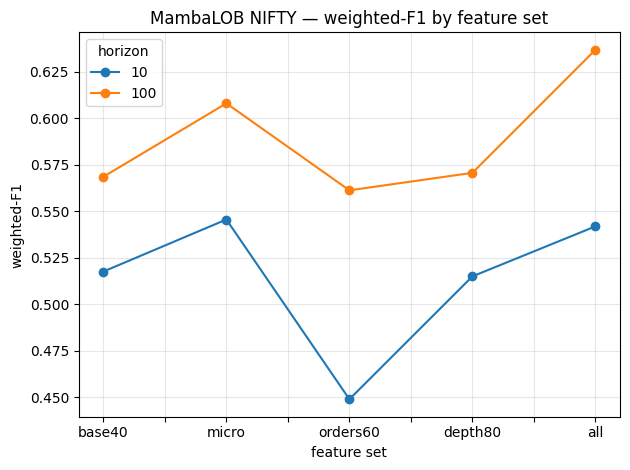


TLOB spot-check (NIFTY k=10):
feature_set  test_weighted_f1  test_macro_f1
     base40            0.5989         0.5789
      micro            0.6063         0.5852


In [8]:
import matplotlib.pyplot as plt
res = pd.read_csv(MERGED)
ORDER = ["base40", "micro", "orders60", "depth80", "all"]
mam = res[res.model == "mambalob"]
piv = mam.pivot_table(index="feature_set", columns="horizon", values="test_weighted_f1").reindex(ORDER)
print("MambaLOB (NIFTY) weighted-F1 by feature set x horizon:")
print(piv.round(4).to_string())
print("\nDelta vs base40 (positive = features help):")
print((piv - piv.loc["base40"]).round(4).to_string())
ax = piv.plot(marker="o"); ax.set(title="MambaLOB NIFTY — weighted-F1 by feature set",
    xlabel="feature set", ylabel="weighted-F1"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("results/fig_feature_ablation.png", dpi=150, bbox_inches="tight")
s3_put_area(s3_client(), "results/fig_feature_ablation.png", AREA); plt.show()
if (res.model == "tlob").any():
    print("\nTLOB spot-check (NIFTY k=10):")
    print(res[res.model == "tlob"][["feature_set", "test_weighted_f1", "test_macro_f1"]].to_string(index=False))